In [1]:
from matplotlib import pyplot as plt
from differential_MFM import MFMData, DifferentialMFMData

Using color range (vmin, vmax): -2.2933e+00,  2.2933e+00


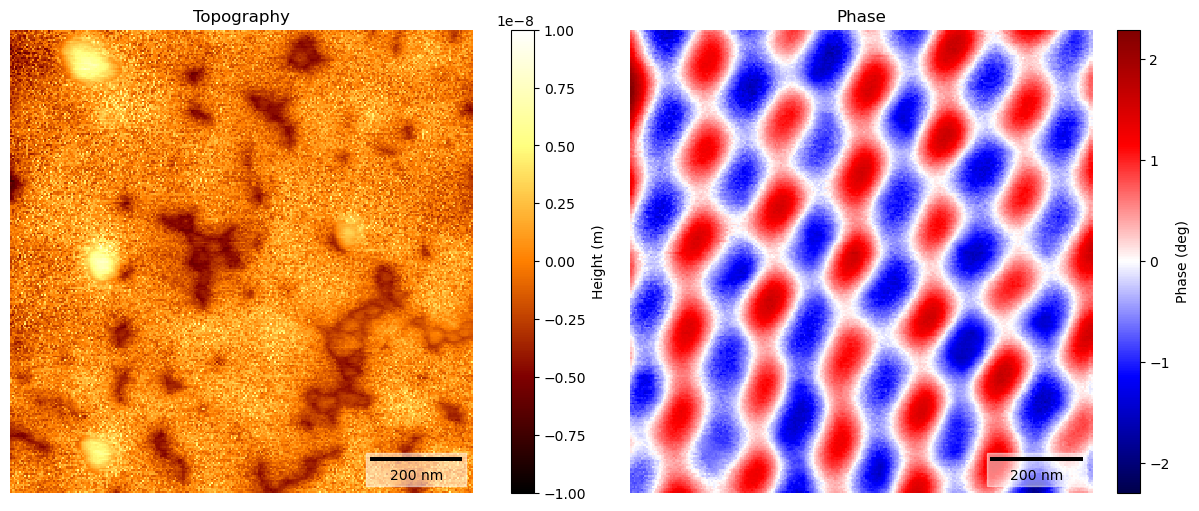

In [2]:
scan_1 = MFMData('./data/1um_25nm.gwy')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
topo_img = scan_1.plot(
    'topo', 
    ax1,
    color_range=(-10e-9, 10e-9),
    color_map='afmhot'
)
ax1.set_title("Topography")
fig.colorbar(topo_img, label="Height (m)")

phase_img = scan_1.plot(
    'phase', 
    ax2, 
    color_map='seismic', 
    color_range='equal'
)
ax2.set_title("Phase")
fig.colorbar(phase_img, label="Phase (deg)")

plt.show()


Using color range (vmin, vmax): -2.3178e+00,  2.3178e+00


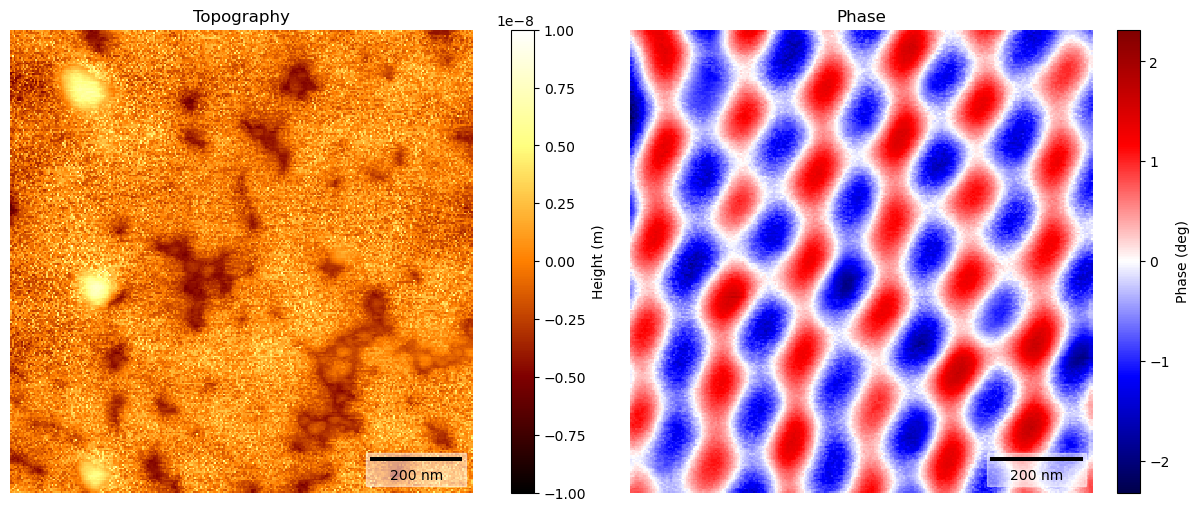

In [3]:
scan_2 = MFMData('./data/1um_25nm_after.gwy')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
topo_img = scan_2.plot(
    'topo', 
    ax1,
    color_range=(-10e-9, 10e-9),
    color_map='afmhot',
)
ax1.set_title("Topography")
fig.colorbar(topo_img, label="Height (m)")

phase_img = scan_2.plot(
    'phase', 
    ax2, 
    color_map='seismic', 
    color_range='equal'
)
ax2.set_title("Phase")
fig.colorbar(phase_img, label="Phase (deg)")

plt.show()

Predicted translation in between scans: [  4 -14]
Using color range (vmin, vmax): -8.8992e-09,  8.8992e-09
Using color range (vmin, vmax): -4.0834e+00,  4.0834e+00


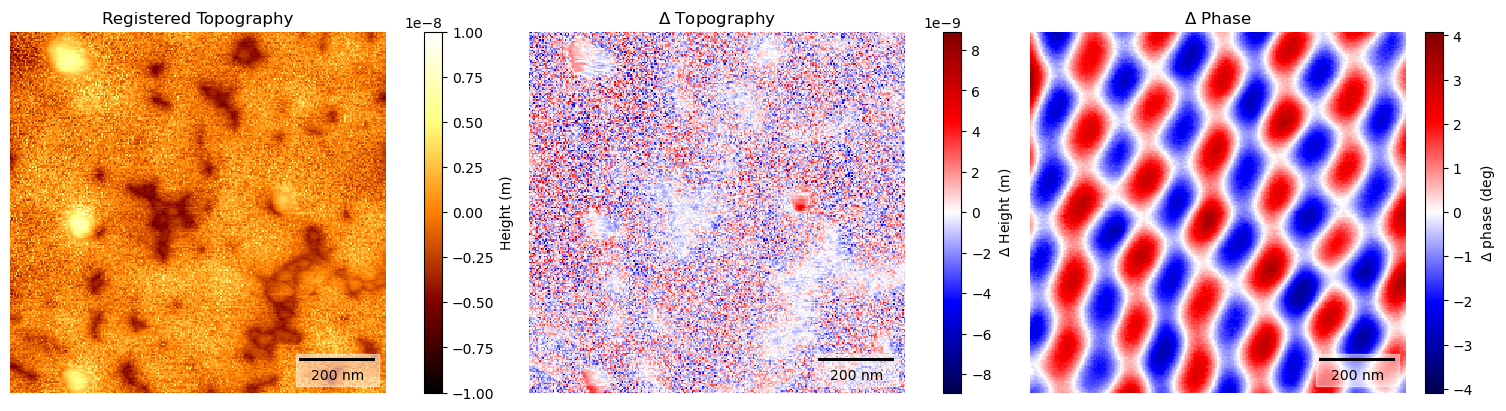

In [9]:
scan_diff = DifferentialMFMData(scan_1, scan_2, method='hill descent')
print(f"Predicted translation in between scans: {scan_diff.registration_result['displacement']}")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4), layout='constrained')
topo_img = scan_diff.plot(
    "topo",
    ax1,
    color_range=(-10e-9, 10e-9),
    color_map="afmhot",
)
ax1.set_title("Registered Topography")
fig.colorbar(topo_img, label="Height (m)")

diff_topo_img = scan_diff.plot(
    "diff_topo",
    ax2,
    color_range='equal',
    color_map='seismic',
)
ax2.set_title(r"$\Delta$ Topography")
fig.colorbar(diff_topo_img, label=r"$\Delta$ Height (m)")

diff_phase_img = scan_diff.plot(
    "phase",
    ax3,
    color_range='equal',
    color_map='seismic',
)
ax3.set_title(r"$\Delta$ Phase")
fig.colorbar(diff_phase_img, label=r"$\Delta$ phase (deg)")

plt.show()

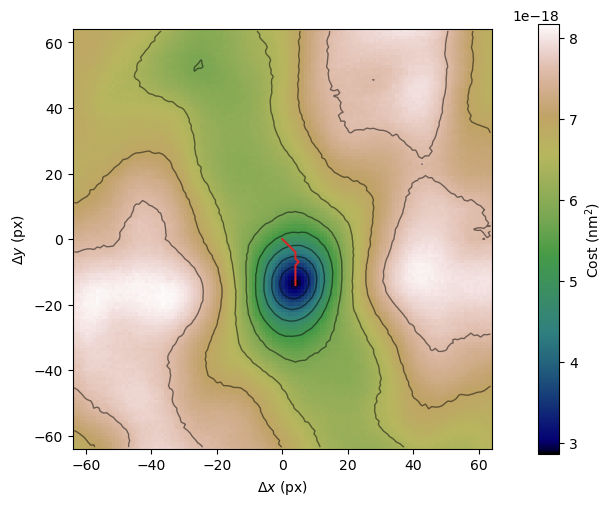

In [20]:
fig, ax = plt.subplots(figsize=(6, 5), layout='constrained')

cost_map_img = scan_diff.plot_cost_map(
    ax,
    del_px=64,
)

path_x = scan_diff.registration_result['path'][:, 0]
path_y = scan_diff.registration_result['path'][:, 1]
plt.plot(path_x, path_y, color="tab:red")

ax.set_xlabel(r"$\Delta x$ (px)")
ax.set_ylabel(r"$\Delta y$ (px)")

fig.colorbar(cost_map_img, label=r"Cost (nm$^2$)")
plt.show()

In [6]:
scan_diff.save_gwy("./export/HDD_diff_scan.gwy")